# Coverage Assignment Validation

This notebook validates the deterministic coverage assignment engine: Voronoi (zone) and motion-correlation (man). It also builds the pre-snap feature matrix for the ML phase.

In [21]:
# Imports and data loading
import sys
import os

sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('.'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.data_processing import filter_tracking_to_play, normalize_play_direction, filter_standard_passes
from src.coverage_assignment import (
    get_snap_frame,
    get_pass_frame,
    get_skill_players,
    get_coverage_defenders,
    compute_voronoi_assignment,
    compute_man_coverage_assignment,
    assign_coverage_responsibility,
)
from src.coverage_features import extract_presnap_features, build_feature_matrix

# Load data (paths relative to project root)
data_dir = Path(os.path.abspath('..')).joinpath('data', 'raw')
if not data_dir.exists():
    data_dir = Path('data') / 'raw'

tracking = pd.read_csv(data_dir / 'week1.csv')
plays = pd.read_csv(data_dir / 'plays.csv')
games = pd.read_csv(data_dir / 'games.csv')

print("Tracking shape:", tracking.shape)
print("Plays shape:", plays.shape)
print("Games shape:", games.shape)

Tracking shape: (1118122, 16)
Plays shape: (8557, 32)
Games shape: (122, 7)


## Filter to standard passes

Use existing `filter_standard_passes` so we only analyze normal dropback passes (no spikes, trick plays, or prevent).

In [22]:
standard_passes = filter_standard_passes(plays)
print(f"Standard passing plays: {len(standard_passes)} (of {len(plays)} total)")
print(f"Coverage type counts:\n{standard_passes['pff_passCoverageType'].value_counts(dropna=False)}")

Standard passing plays: 7457 (of 8557 total)
Coverage type counts:
pff_passCoverageType
Zone     4918
Man      2154
Other     385
Name: count, dtype: int64


## Single play deep dive

TB vs DAL, Cover-1 Man play (game_id=2021090900, play_id=97). Run `assign_coverage_responsibility` and display assignments.

In [23]:
game_id = 2021090900
play_id = 97

result = assign_coverage_responsibility(tracking, plays, game_id, play_id)
if result is None:
    print("No result (missing tracking or snap frame)")
else:
    print(f"Coverage type: {result['coverage_type']} | Scheme: {result['coverage_scheme']}")
    print(f"Snap frame: {result['snap_frame']} | Pass frame: {result['pass_frame']}")
    print(f"Offense: {result['offense_team']} | Defense: {result['defense_team']}\n")
    assignments_df = result['assignments_df']
    if len(assignments_df) == 0:
        print("No assignments (no skill players or coverage defenders at snap)")
    else:
        display_cols = ['receiver_jersey', 'receiver_position', 'assigned_defender_jersey',
                       'assigned_defender_position', 'cushion_distance', 'assignment_method']
        if 'motion_correlation' in assignments_df.columns:
            display_cols.extend(['avg_distance', 'motion_correlation', 'composite_score'])
        print(assignments_df[display_cols].to_string(index=False))

Coverage type: Man | Scheme: Cover-1
Snap frame: 6 | Pass frame: 40
Offense: TB | Defense: DAL

 receiver_jersey receiver_position  assigned_defender_jersey assigned_defender_position  cushion_distance assignment_method  avg_distance  motion_correlation  composite_score
            12.0           Unknown                       6.0                    Unknown         10.592799        man_motion     12.411851            0.628128         0.518263
            87.0           Unknown                      42.0                    Unknown          3.030017        man_motion      1.735746            0.808772         0.688844
            81.0           Unknown                      30.0                    Unknown          2.706917        man_motion      1.348791            0.870059         0.731318
            25.0           Unknown                      26.0                    Unknown         15.759813        man_motion     15.251139            0.523031         0.481523
            66.0           Un

## Visualize Voronoi zones on field

Draw defenders, receivers, Voronoi cell boundaries clipped to field, and assignment lines. Save to `outputs/voronoi_assignment_example.png`.

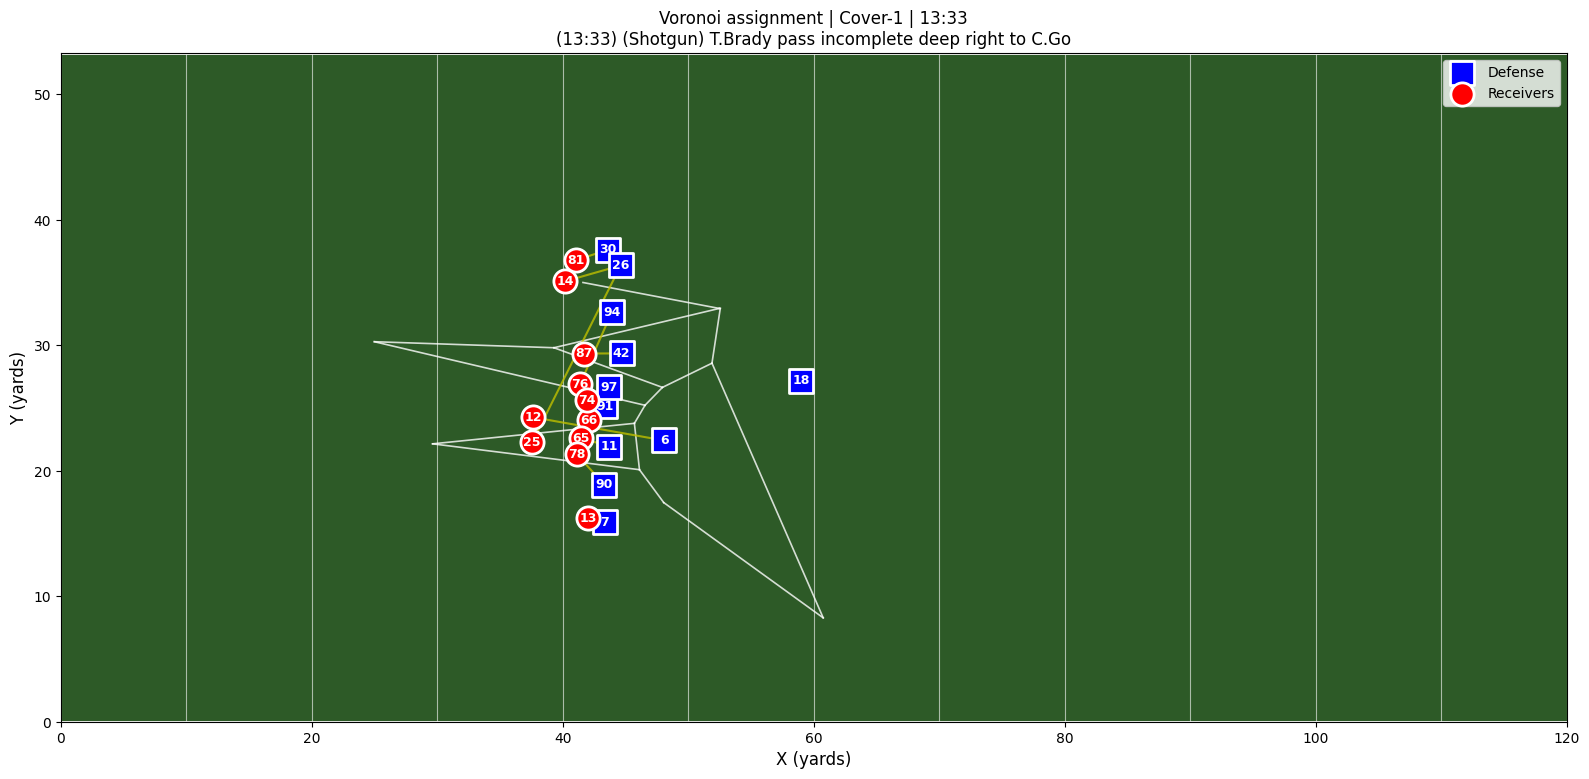

Saved to outputs/voronoi_assignment_example.png


In [24]:
# Use same play; get snap frame data for Voronoi
play_tracking = filter_tracking_to_play(tracking, game_id, play_id)
play_tracking = normalize_play_direction(play_tracking)
snap_frame = get_snap_frame(play_tracking)
snap_df = play_tracking[play_tracking['frameId'] == snap_frame]
ball = snap_df[snap_df['team'] == 'football']
ball_x = float(ball['x'].iloc[0]) if len(ball) > 0 else None
receivers = get_skill_players(snap_df, result['offense_team'])
defenders = get_coverage_defenders(snap_df, result['defense_team'], ball_x=ball_x)
assignments = result['assignments_df']

play_meta = plays[(plays['gameId'] == game_id) & (plays['playId'] == play_id)].iloc[0]
title_desc = play_meta.get('playDescription', '')[:60]
game_clock = play_meta.get('gameClock', '')

from scipy.spatial import Voronoi
def_xy = defenders[['x', 'y']].values
vor = Voronoi(def_xy)

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_facecolor('#2d5a27')
ax.set_xlim(0, 120)
ax.set_ylim(0, 53.3)
ax.set_aspect('equal')

# Yard lines every 10 yards
for x in range(0, 121, 10):
    ax.axvline(x=x, color='white', linewidth=0.8, alpha=0.6)
ax.axhline(y=0, color='white', linewidth=2)
ax.axhline(y=53.3, color='white', linewidth=2)

# Voronoi ridges clipped to field (only draw if both endpoints inside)
for ridge_vertices in vor.ridge_vertices:
    if -1 in ridge_vertices:
        continue
    p0 = vor.vertices[ridge_vertices[0]]
    p1 = vor.vertices[ridge_vertices[1]]
    if (0 <= p0[0] <= 120 and 0 <= p0[1] <= 53.3 and
        0 <= p1[0] <= 120 and 0 <= p1[1] <= 53.3):
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], 'w-', linewidth=1.2, alpha=0.8)

# Defenders (blue squares) and receivers (red circles)
ax.scatter(defenders['x'], defenders['y'], c='blue', s=280, marker='s', edgecolors='white', linewidth=2, zorder=4, label='Defense')
ax.scatter(receivers['x'], receivers['y'], c='red', s=280, marker='o', edgecolors='white', linewidth=2, zorder=4, label='Receivers')
for _, r in receivers.iterrows():
    j = r.get('jerseyNumber', '')
    if pd.notna(j): ax.text(r['x'], r['y'], str(int(j)), ha='center', va='center', color='white', fontsize=9, weight='bold', zorder=5)
for _, d in defenders.iterrows():
    j = d.get('jerseyNumber', '')
    if pd.notna(j): ax.text(d['x'], d['y'], str(int(j)), ha='center', va='center', color='white', fontsize=9, weight='bold', zorder=5)

# Assignment lines
for _, row in assignments.iterrows():
    ax.plot([row['receiver_x'], row['assigned_defender_x']], [row['receiver_y'], row['assigned_defender_y']],
            'y-', linewidth=1.5, alpha=0.8, zorder=3)

ax.set_xlabel('X (yards)', fontsize=12)
ax.set_ylabel('Y (yards)', fontsize=12)
ax.set_title(f'Voronoi assignment | {result["coverage_scheme"]} | {game_clock}\n{title_desc}', fontsize=12)
ax.legend(loc='upper right')
Path('outputs').mkdir(exist_ok=True)
plt.tight_layout()
plt.savefig('outputs/voronoi_assignment_example.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/voronoi_assignment_example.png')

## Man coverage motion correlation

Pick a known Man coverage play, run `compute_man_coverage_assignment`, plot receiver routes and defender paths, draw assignment lines, and show motion correlation heatmap (receivers x defenders).

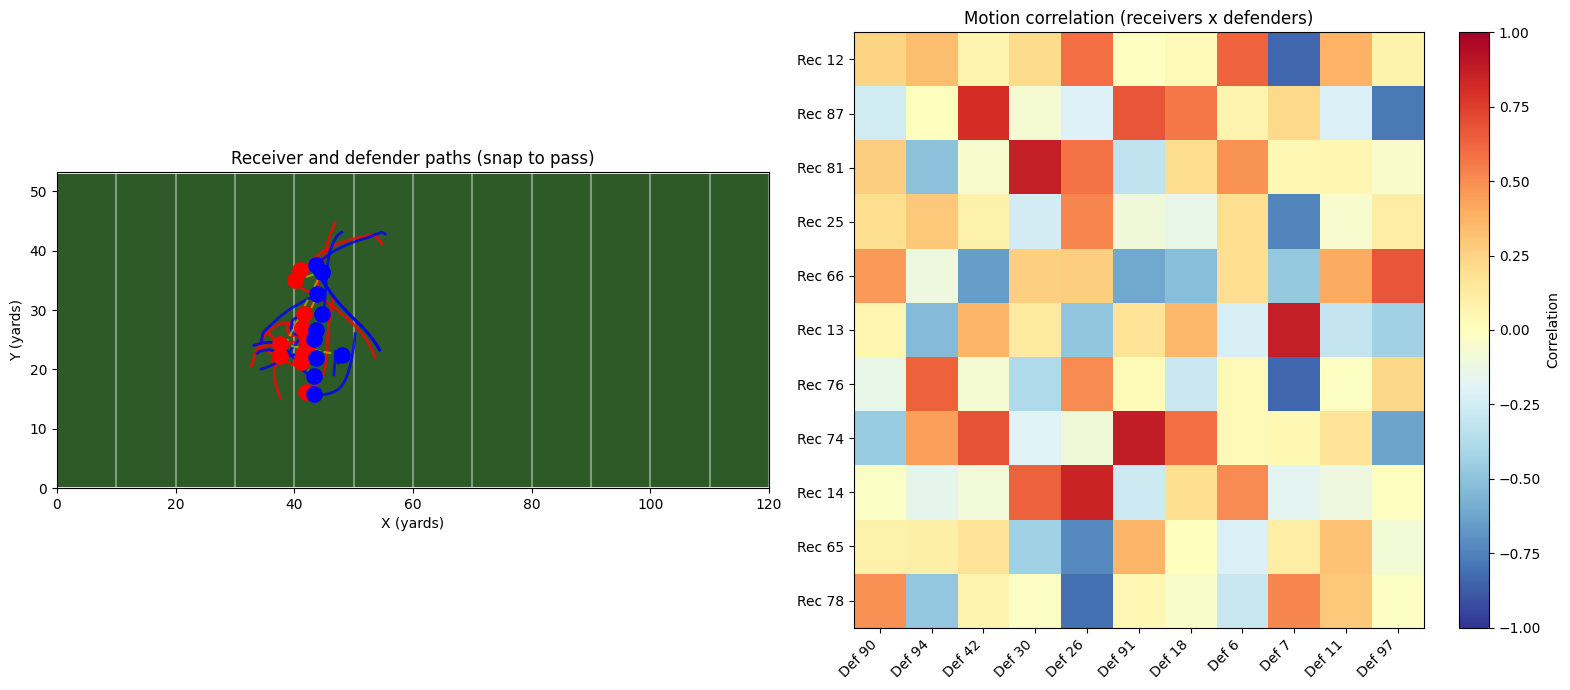

In [25]:
# Pick first Man coverage play in standard passes
from src.coverage_assignment import compute_man_correlation_matrix

man_plays = standard_passes[standard_passes['pff_passCoverageType'] == 'Man']
if len(man_plays) == 0:
    print("No Man coverage plays in standard_passes")
else:
    row = man_plays.iloc[0]
    gid, pid = int(row['gameId']), int(row['playId'])
    res = assign_coverage_responsibility(tracking, plays, gid, pid)
    if res is None or len(res['assignments_df']) == 0:
        print("Assignment failed for first Man play")
    else:
        pt = filter_tracking_to_play(tracking, gid, pid)
        pt = normalize_play_direction(pt)
        snap_f = res['snap_frame']
        pass_f = res['pass_frame'] or pt['frameId'].max()
        frames = sorted(pt['frameId'].unique())
        frames = [f for f in frames if snap_f <= f <= pass_f]
        snap_df = pt[pt['frameId'] == snap_f]
        ball = snap_df[snap_df['team'] == 'football']
        ball_x = float(ball['x'].iloc[0]) if len(ball) > 0 else None
        receivers = get_skill_players(snap_df, res['offense_team'])
        defenders = get_coverage_defenders(snap_df, res['defense_team'], ball_x=ball_x)
        _, corr_matrix = compute_man_correlation_matrix(receivers, defenders, pt, snap_f, pass_f)
        rec_ids = res['assignments_df']['receiver_nflId'].dropna().astype(int).tolist()
        def_ids = res['assignments_df']['assigned_defender_nflId'].dropna().astype(int).tolist()

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
        ax1.set_facecolor('#2d5a27')
        ax1.set_xlim(0, 120)
        ax1.set_ylim(0, 53.3)
        ax1.set_aspect('equal')
        for x in range(0, 121, 10):
            ax1.axvline(x=x, color='white', alpha=0.4)
        ax1.axhline(y=0, color='white', linewidth=2)
        ax1.axhline(y=53.3, color='white', linewidth=2)

        for nflid in rec_ids:
            sub = pt[pt['nflId'] == nflid].set_index('frameId').reindex(frames).sort_index()
            sub = sub.ffill().bfill()
            if len(sub) > 0:
                ax1.plot(sub['x'], sub['y'], 'r-', linewidth=2, alpha=0.8)
                ax1.scatter(sub['x'].iloc[0], sub['y'].iloc[0], c='red', s=120, zorder=5)
        for nflid in def_ids:
            sub = pt[pt['nflId'] == nflid].set_index('frameId').reindex(frames).sort_index()
            sub = sub.ffill().bfill()
            if len(sub) > 0:
                ax1.plot(sub['x'], sub['y'], 'b-', linewidth=2, alpha=0.8)
                ax1.scatter(sub['x'].iloc[0], sub['y'].iloc[0], c='blue', s=120, zorder=5)
        for _, r in res['assignments_df'].iterrows():
            ax1.plot([r['receiver_x'], r['assigned_defender_x']], [r['receiver_y'], r['assigned_defender_y']], 'y--', alpha=0.7)
        ax1.set_title('Receiver and defender paths (snap to pass)')
        ax1.set_xlabel('X (yards)')
        ax1.set_ylabel('Y (yards)')

        # Heatmap: receivers x defenders motion correlation
        if corr_matrix.size > 0:
            rec_labels = [str(int(r)) for r in res['assignments_df']['receiver_jersey'].tolist()]
            def_labels = [str(int(d)) for d in defenders['jerseyNumber'].tolist()] if len(defenders) == corr_matrix.shape[1] else [str(j) for j in range(corr_matrix.shape[1])]
            im = ax2.imshow(corr_matrix, cmap='RdYlBu_r', vmin=-1, vmax=1, aspect='auto')
            ax2.set_yticks(range(len(rec_labels)))
            ax2.set_yticklabels([f'Rec {r}' for r in rec_labels])
            ax2.set_xticks(range(corr_matrix.shape[1]))
            ax2.set_xticklabels([f'Def {d}' for d in def_labels], rotation=45, ha='right')
            ax2.set_title('Motion correlation (receivers x defenders)')
            plt.colorbar(im, ax=ax2, label='Correlation')
        plt.tight_layout()
        plt.show()

## Batch validation

Run man-motion correlation on all standard passes in week1. Collect per-play metrics (mean, max, min, std of motion correlation across receivers) and compare a heuristic Man/Zone prediction to `pff_passCoverageType`.

**Improved heuristic:** Instead of a single low threshold on mean correlation, we use two signals:
- **Mean correlation** — higher in man coverage (defenders track receivers)
- **Min correlation** — in man coverage, *all* receivers are tracked, so even the lowest correlation stays elevated

A play is predicted as Man when mean correlation > 0.5 **and** min correlation > 0.2.

In [ ]:
games_in_week1 = tracking['gameId'].unique()
plays_to_run = filter_standard_passes(plays[plays['gameId'].isin(games_in_week1)])

results = []
for _, row in plays_to_run.iterrows():
    gid, pid = int(row['gameId']), int(row['playId'])
    pt = filter_tracking_to_play(tracking, gid, pid)
    if len(pt) == 0:
        continue
    pt = normalize_play_direction(pt)
    snap_f = get_snap_frame(pt)
    pass_f = get_pass_frame(pt)
    if snap_f is None:
        continue
    play_meta = plays[(plays['gameId']==gid)&(plays['playId']==pid)].iloc[0]
    off_team = play_meta['possessionTeam']
    def_team = play_meta['defensiveTeam']
    snap_df = pt[pt['frameId']==snap_f]
    ball = snap_df[snap_df['team']=='football']
    ball_x = float(ball['x'].iloc[0]) if len(ball) > 0 else None
    rec = get_skill_players(snap_df, off_team)
    defs = get_coverage_defenders(snap_df, def_team, ball_x=ball_x)
    if len(rec)==0 or len(defs)==0:
        continue
    man_assign = compute_man_coverage_assignment(rec, defs, pt, snap_f, pass_f)
    true_type = row.get('pff_passCoverageType')

    corr_vals = man_assign['motion_correlation'] if 'motion_correlation' in man_assign.columns else pd.Series(dtype=float)
    corr_vals = corr_vals.dropna()

    if len(corr_vals) > 0:
        mean_corr = corr_vals.mean()
        max_corr = corr_vals.max()
        min_corr = corr_vals.min()
        std_corr = corr_vals.std() if len(corr_vals) > 1 else 0.0
        pred_type = 'Man' if (mean_corr > 0.5 and min_corr > 0.2) else 'Zone'
    else:
        mean_corr = max_corr = min_corr = std_corr = np.nan
        pred_type = 'Zone'

    results.append({
        'game_id': gid, 'play_id': pid,
        'true': true_type, 'pred': pred_type,
        'mean_corr': mean_corr, 'max_corr': max_corr,
        'min_corr': min_corr, 'std_corr': std_corr,
    })

res_df = pd.DataFrame(results)
res_df = res_df.dropna(subset=['true'])

if len(res_df) == 0:
    print("No plays with ground truth coverage type")
else:
    from sklearn.metrics import confusion_matrix, accuracy_score
    acc = accuracy_score(res_df['true'], res_df['pred'])
    print(f"Accuracy (heuristic Man/Zone vs pff_passCoverageType): {acc:.2%}")
    print("\nConfusion matrix (rows=true, cols=pred):")
    labels = sorted(set(res_df['true'].dropna().unique().tolist() + res_df['pred'].unique().tolist()))
    cm = confusion_matrix(res_df['true'], res_df['pred'], labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    print(cm_df)

Accuracy (heuristic Man/Zone vs pff_passCoverageType): 27.65957%

Confusion matrix (rows=true, cols=pred):
       Man  Other  Zone
Man    286      0     0
Other   58      0     0
Zone   690      0     0


In [ ]:
if len(res_df) > 0:
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    for ax, col, title in zip(axes, ['mean_corr', 'max_corr', 'min_corr', 'std_corr'],
                               ['Mean Correlation', 'Max Correlation', 'Min Correlation', 'Std Correlation']):
        for label in ['Man', 'Zone']:
            subset = res_df[res_df['true'] == label][col].dropna()
            if len(subset) > 0:
                ax.hist(subset, bins=30, alpha=0.6, label=f'{label} (n={len(subset)})')
        ax.set_title(title, fontsize=12, weight='bold')
        ax.set_xlabel('Correlation value')
        ax.set_ylabel('Count')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle('Motion Correlation Distributions: True Man vs True Zone', fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

    print("\nSummary statistics by true coverage type:")
    for label in ['Man', 'Zone', 'Other']:
        sub = res_df[res_df['true'] == label]
        if len(sub) > 0:
            print(f"\n  {label} (n={len(sub)}):")
            print(f"    mean_corr:  mean={sub['mean_corr'].mean():.3f}  median={sub['mean_corr'].median():.3f}")
            print(f"    min_corr:   mean={sub['min_corr'].mean():.3f}  median={sub['min_corr'].median():.3f}")
            print(f"    max_corr:   mean={sub['max_corr'].mean():.3f}  median={sub['max_corr'].median():.3f}")

## Feature matrix preview

Build the pre-snap feature matrix for all plays, show shape and statistics, and plot histograms of each feature split by Man vs Zone.

In [ ]:
# Build feature matrix (all plays in plays that have tracking)
feat_df = build_feature_matrix(tracking, plays)
print("Feature matrix shape:", feat_df.shape)
print("\nFirst 5 rows:")
display(feat_df.head())
print("\nDescribe:")
display(feat_df.describe())

# Histograms by Man vs Zone
feat_cols = [c for c in feat_df.columns if c not in ('game_id', 'play_id', 'pff_passCoverageType', 'pff_passCoverage')]
feat_df_clean = feat_df.dropna(subset=['pff_passCoverageType'])
if len(feat_df_clean) > 0 and feat_cols:
    ncols = 3
    nrows = (len(feat_cols) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
    axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()
    for i, col in enumerate(feat_cols):
        ax = axes[i]
        for label in feat_df_clean['pff_passCoverageType'].dropna().unique():
            subset = feat_df_clean[feat_df_clean['pff_passCoverageType'] == label][col].dropna()
            ax.hist(subset, bins=20, alpha=0.6, label=str(label))
        ax.set_title(col)
        ax.legend()
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()